### **1. 라이브러리 호출**

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
from pprint import pprint

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
import platform


warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 데이터프레임 출력제한 해제
pd.set_option('display.max_rows', None)      # 행 제한 해제
pd.set_option('display.max_columns', None)   # 열 제한 해제
pd.set_option('display.max_colwidth', None)  # 셀 내용 제한 해제

### **2. 데이터 전처리**

In [2]:
# 데이터 확인

df_shorts = pd.read_csv("../../data/results/preprocessed/fnb_shorts_df.csv", encoding='utf-8')

print(df_shorts.columns.tolist())
print('='*60)
print(df_shorts.info())

['video_id', 'title', 'channel_id', 'channel_title', 'description', 'upload_date', 'tags', 'view_count', 'like_count', 'comment_count', 'duration', 'definition', 'license', 'embeddable', 'has_paid_product_placement', 'thumbnail', 'caption', 'final_url', 'instream_type', 'channel_handle', 'channel_tier', 'subscriber_count', 'domain', 'description_missing_flag', 'tags_missing_flag', 'er', 'ler', 'cer', 'wei', 'description_length', 'category_name', 'upload_year', 'upload_month', 'upload_dayofweek', 'upload_hour', 'tags_count', 'upload_quarter', 'upload_ym_quarter', 'upload_ymd']
<class 'pandas.DataFrame'>
RangeIndex: 6942 entries, 0 to 6941
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   video_id                    6942 non-null   str    
 1   title                       6942 non-null   str    
 2   channel_id                  6942 non-null   str    
 3   channel_title               694

In [3]:
# 데이터 타입 변환
df_shorts['upload_date'] = pd.to_datetime(df_shorts['upload_date']).dt.tz_localize(None)

# 확인
print(df_shorts['upload_date'].dtype) # datetime64[us]
print(df_shorts['upload_date'].head(1)) # 2026-04-24 09:00:31

datetime64[us]
0   2026-04-24 09:00:31
Name: upload_date, dtype: datetime64[us]


### **3. 파생변수 제작 및 데이터 필터링**

In [4]:
# 수집 마지막 날짜를 기준점으로 설정 (경과 일 수 계산 기준)
REFERENCE_DATE = pd.Timestamp("2026-04-27")

# 기준일 - 업로드일 = 영상업로드 후 경과일
df_shorts['elapsed_days'] = (REFERENCE_DATE - df_shorts['upload_date']).dt.days

# 업로드 당일 수집된 영상은 경과일이 0이 되어 RR 계산 시 분모가 0이 됨 -> NaN 처리
df_shorts['elapsed_days'] = df_shorts['elapsed_days'].replace(0, float('nan'))

In [5]:
# 분석 대상 영상 필터링-1 (2021.10.13 ~ 2026.03.27)
ANALYSIS_START = pd.Timestamp("2021-10-13")
ANALYSIS_END = pd.Timestamp("2026-03-27")

df_target = df_shorts[
    (df_shorts['upload_date'] >= ANALYSIS_START)&
    (df_shorts['upload_date'] <= ANALYSIS_END)
].copy()

print(df_target.info())

<class 'pandas.DataFrame'>
Index: 6613 entries, 11 to 6941
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   video_id                    6613 non-null   str           
 1   title                       6613 non-null   str           
 2   channel_id                  6613 non-null   str           
 3   channel_title               6613 non-null   str           
 4   description                 6613 non-null   str           
 5   upload_date                 6613 non-null   datetime64[us]
 6   tags                        6613 non-null   str           
 7   view_count                  6613 non-null   int64         
 8   like_count                  6613 non-null   float64       
 9   comment_count               6613 non-null   float64       
 10  duration                    6613 non-null   float64       
 11  definition                  6613 non-null   str           
 12  license

In [6]:
# 분석 대상 영상 필터링-2 (조회수 하위 5% 영상 제거)
view_cnt_5pct = df_target['view_count'].quantile(0.05)

df_target_main = df_target[df_target['view_count']>view_cnt_5pct].copy()

print(f"하위 5% 영상의 조회수: {view_cnt_5pct}")
print('='*60)
print(df_target_main.info())

하위 5% 영상의 조회수: 336.0
<class 'pandas.DataFrame'>
Index: 6281 entries, 11 to 6941
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   video_id                    6281 non-null   str           
 1   title                       6281 non-null   str           
 2   channel_id                  6281 non-null   str           
 3   channel_title               6281 non-null   str           
 4   description                 6281 non-null   str           
 5   upload_date                 6281 non-null   datetime64[us]
 6   tags                        6281 non-null   str           
 7   view_count                  6281 non-null   int64         
 8   like_count                  6281 non-null   float64       
 9   comment_count               6281 non-null   float64       
 10  duration                    6281 non-null   float64       
 11  definition                  6281 non-null   str   

In [7]:
# RR 계산
# (총 조회수/업로드 후 경과일수)/구독자수

df_target_main['RR'] = (df_target_main['view_count']/df_target_main['elapsed_days']) / df_target_main['subscriber_count']

In [8]:
channel_cnt = df_target_main['channel_id'].value_counts()

print(f"\n채널 수: {df_target_main['channel_id'].nunique()}")
print(f"\n[채널별 영상 수]\n{channel_cnt}")


채널 수: 61

[채널별 영상 수]
channel_id
UCl0HemfAt7dShJRf59_cuGQ    683
UCsM07dUwo0WOWhFbVsG8K6A    540
UCaxvyTYdWaDXupmgj5ttDUQ    447
UCSQ0lVqv57JVw1lOdJ2vTVA    445
UCC3eqZIo6lqZQQAN9MO0LQA    390
UCnL1m_iPeN8vX7zFHoB4SYg    256
UCHvCHuXTg6yfQQ1QCeDQMLg    242
UCFXwXfbr4b1HHl-YKCOaydA    239
UCzGara7SUTKXruclCD4eA5g    193
UCbEEgpyRxXd6rbM_xhApb_Q    164
UC-WFvgdXXmZPj4pDI8GFbzQ    162
UCfv1dkNKCFUtZouvp3DhS3g    152
UCDryA2PIGnbs9NYn_63rISw    147
UCt0Pnki9ZDDYx6auEtClYLQ    142
UCzCxSb_RYZuaiaP3u9QNR_A    131
UC4xGgCpoPfLHcuPeUbnMibA    121
UCzGbclHB9ZcrbcV4qg11C1A    102
UC-9HdRV-OzriZ1Q09bT304w     93
UCzKFT7cBIKO9Dapikf6e3ow     92
UCpvT-53Ki7d9Z0PWKC6fGOA     88
UCIAFN5e9KzBu_F3dBDbmmVg     82
UCuJkoRqYKKCwagZhmz6my-g     80
UCOV_BpGzvmH7ZtjQOWg0bSQ     78
UClgbMkn177O0xNOEcR9rtug     74
UChD4kH8BcI49njXGL5-makg     72
UC9Hu-7OguU6HyWaxP_GBYcA     72
UCtAHe2OINYIyGOTLDSCzFFg     71
UCGmLtNZFTL6PiKsz3Vpdgbw     70
UCEKRI0fipK4LEgV98nI2CQA     64
UCmvqXRPTfMgkKF3MFWylMqQ     63
UCPz4i6

In [9]:
print(f"영상 10개 미만 채널 수: {(channel_cnt < 10).sum()}개")
print(f"영상 10개 이상 채널 수: {(channel_cnt >= 10).sum()}개")
print(f"\n[영상 수 통계]\n{channel_cnt.describe()}")

영상 10개 미만 채널 수: 10개
영상 10개 이상 채널 수: 51개

[영상 수 통계]
count     61.000000
mean     102.967213
std      138.138212
min        1.000000
25%       16.000000
50%       55.000000
75%      121.000000
max      683.000000
Name: count, dtype: float64


In [10]:
# 구간별 채널 수 및 채널 비율 확인
total_channels = len(channel_cnt)

for threshold in [5, 10, 15, 20]:
    below_channels = (channel_cnt < threshold).sum()
    above_channels = (channel_cnt >= threshold).sum()
    below_pct = below_channels / total_channels * 100

    print(f"기준 {threshold:2d}개 → "
          f"기준 미만: {below_channels}개 채널 ({below_pct:.1f}%) / "
          f"기준 이상: {above_channels}개 채널 ({100 - below_pct:.1f}%)")

기준  5개 → 기준 미만: 5개 채널 (8.2%) / 기준 이상: 56개 채널 (91.8%)
기준 10개 → 기준 미만: 10개 채널 (16.4%) / 기준 이상: 51개 채널 (83.6%)
기준 15개 → 기준 미만: 14개 채널 (23.0%) / 기준 이상: 47개 채널 (77.0%)
기준 20개 → 기준 미만: 16개 채널 (26.2%) / 기준 이상: 45개 채널 (73.8%)


In [11]:
# 컬럼명 변경
df_target_main = df_target_main.rename(columns={
    # 기본 정보
    'channel_title'    : '채널명',
    'upload_date'      : '업로드일시',
    'duration'         : '영상길이(초)',

    # 수치 지표
    'view_count'       : '조회수',
    'like_count'       : '좋아요수',
    'comment_count'    : '댓글수',
    'subscriber_count' : '구독자수',

    # 파생 지표
    'elapsed_days'     : '경과일수',
    'RR'               : '도달률(RR)',       # Reach Rate
    'er'               : '참여율(ER)',       # Engagement Rate
    'ler'              : '조회수 대비 좋아요율',     # Like Engagement Rate
    'cer'              : '조회수 대비 댓글률',       # Comment Engagement Rate
})

# 결과 확인
pprint(df_target_main.columns.tolist())

['video_id',
 'title',
 'channel_id',
 '채널명',
 'description',
 '업로드일시',
 'tags',
 '조회수',
 '좋아요수',
 '댓글수',
 '영상길이(초)',
 'definition',
 'license',
 'embeddable',
 'has_paid_product_placement',
 'thumbnail',
 'caption',
 'final_url',
 'instream_type',
 'channel_handle',
 'channel_tier',
 '구독자수',
 'domain',
 'description_missing_flag',
 'tags_missing_flag',
 '참여율(ER)',
 '조회수 대비 좋아요율',
 '조회수 대비 댓글률',
 'wei',
 'description_length',
 'category_name',
 'upload_year',
 'upload_month',
 'upload_dayofweek',
 'upload_hour',
 'tags_count',
 'upload_quarter',
 'upload_ym_quarter',
 'upload_ymd',
 '경과일수',
 '도달률(RR)']


In [12]:
# 일평균 조회수 = 조회수 / 경과일수
df_target_main['일평균 조회수'] = df_target_main['조회수'] / df_target_main['경과일수']

# 결과 확인
print(df_target_main['일평균 조회수'].describe())

count      6281.000000
mean       1355.442497
std       14352.189187
min           0.236364
25%           4.945600
50%          32.433333
75%         184.901836
max      673653.156250
Name: 일평균 조회수, dtype: float64


---
### 4. 지표 1
- ER과 RR을 활용하는 지표
- 가중치를 구하는 방법 (후보)
    - CV 기반 ✅ 채택
        - 두 지표가 독립적이라는 가정 하에 CV값이 더 큰 값이 영상간의 차이를 변별하기 좋을 것이기 때문에 더 높은 가중치 부여
    - PCA 기반 ❌ 불가
        - RR과 ER을 PCA에 넣었을 때, 전체 분산을 가장 잘 설명하는 첫번째 주성분(PC1)에서 각 변수의 기여도(loading)를
        w1, w2로 사용하는 방법
        - 변수가 2개일 때 표준화된 데이터에서 PC1의 loading² + PC2의 loading²이
          항상 동일하게 나와 수학적으로 가중치 차별화가 불가능

In [13]:
# -------------------------------------------------------
# CV(변동계수) 기반 채널별 가중치(w1, w2) 산출
# RR과 ER 중 채널 내 영상 간 변별력이 높은 지표에 높은 가중치 부여
# -------------------------------------------------------
channel_weights = {} # 채널별 가중치

for channel_id, group in df_target_main.groupby('channel_id'):

    # 영상 10개 미만 채널은 CV 계산이 불안정하므로 균등 가중치 적용 (영상 개수는 협의 필요)
    if len(group) < 10:
        channel_weights[channel_id] = {'w1': 0.5, 'w2': 0.5}
        continue

    # CV = 표준편차 / 평균
    # CV가 클수록 영상 간 차이를 더 잘 변별하는 지표
    cv_rr = group['도달률(RR)'].std() / group['도달률(RR)'].mean()
    cv_er = group['참여율(ER)'].std() / group['참여율(ER)'].mean()
    cv_sum = cv_rr + cv_er

    # cv_sum이 0인 경우 (모든 영상의 RR, ER이 동일) 균등 가중치 적용
    if cv_sum == 0:
        channel_weights[channel_id] = {'w1': 0.5, 'w2': 0.5}
        continue

    channel_weights[channel_id] = {
        'w1': cv_rr / cv_sum,  # RR의 변별력 비율
        'w2': cv_er / cv_sum   # ER의 변별력 비율
    }

# 딕셔너리 → DataFrame으로 변환 (행: channel_id, 열: w1, w2)
channel_weights_df = pd.DataFrame(channel_weights).T
channel_weights_df.index.name = 'channel_id'

# 확인
print(f"[채널별 가중치]")
print(channel_weights_df)
print(f"\n[가중치 통계]")
print(channel_weights_df.describe())
print(f"\n균등 가중치 적용 채널 수: {(channel_cnt < 10).sum()}개")

[채널별 가중치]
                                w1        w2
channel_id                                  
UC-9HdRV-OzriZ1Q09bT304w  0.703220  0.296780
UC-WFvgdXXmZPj4pDI8GFbzQ  0.759785  0.240215
UC4xGgCpoPfLHcuPeUbnMibA  0.896796  0.103204
UC88W-nkd_7G9S7u-2xlX4DQ  0.736658  0.263342
UC9Hu-7OguU6HyWaxP_GBYcA  0.648685  0.351315
UC9_GC5aoZJMz5MAH9e8x9Yg  0.500000  0.500000
UCC-RQrzmKSAV70txxsdXWqQ  0.451196  0.548804
UCC3eqZIo6lqZQQAN9MO0LQA  0.632615  0.367385
UCDjdk0ufvcvV08hAm_vF06Q  0.712071  0.287929
UCDryA2PIGnbs9NYn_63rISw  0.795757  0.204243
UCEKRI0fipK4LEgV98nI2CQA  0.846932  0.153068
UCFRMEa0vlRfrgcQpnryE-TA  0.643236  0.356764
UCFXwXfbr4b1HHl-YKCOaydA  0.704001  0.295999
UCG_gfzGVpsxGwYuFgH8-tNA  0.500000  0.500000
UCGmLtNZFTL6PiKsz3Vpdgbw  0.626494  0.373506
UCHvCHuXTg6yfQQ1QCeDQMLg  0.772953  0.227047
UCIAFN5e9KzBu_F3dBDbmmVg  0.490857  0.509143
UCMqZKRBemgZ0_1uLT2yAF9w  0.520428  0.479572
UCOV_BpGzvmH7ZtjQOWg0bSQ  0.830527  0.169473
UCOx-g_rEMW3oD8g-bQaLWkQ  0.500000  0.500000


In [14]:
# 가중치의 평균값 적용
# 다양한 채널의 특성을 반영했으면서도 모든 영상에 동일한 기준을 적용하면 다른 채널의 영상끼리도 비교하기 좋을 것 같음
w1 = channel_weights_df['w1'].mean()
w2 = channel_weights_df['w2'].mean()

print(f"w1 (RR 가중치): {w1:.4f}") # w1 (RR 가중치): 0.6688
print(f"w2 (ER 가중치): {w2:.4f}") # w2 (ER 가중치): 0.3312

w1 (RR 가중치): 0.6688
w2 (ER 가중치): 0.3312


In [15]:
# 전체 영상을 기준으로 백분위 계산
# rank(pct=True): 0~1 사이 백분위로 변환
df_target_main['RR_백분위'] = df_target_main['도달률(RR)'].rank(pct=True)
df_target_main['ER_백분위'] = df_target_main['참여율(ER)'].rank(pct=True)

# score1 = w1 * RR백분위 + w2 * ER백분위
# 0~1 사이 값, 높을수록 성과가 좋은 영상
df_target_main['score1'] = (
    w1 * df_target_main['RR_백분위'] + w2 * df_target_main['ER_백분위']
)

# 결과 확인
print(f"[score1 통계]")
print(df_target_main['score1'].describe())
print(f"\n[RR_백분위 통계]")
print(df_target_main['RR_백분위'].describe())
print(f"\n[ER_백분위 통계]")
print(df_target_main['ER_백분위'].describe())

[score1 통계]
count    6281.000000
mean        0.500080
std         0.171830
min         0.073335
25%         0.359515
50%         0.508872
75%         0.635689
max         0.970780
Name: score1, dtype: float64

[RR_백분위 통계]
count    6281.000000
mean        0.500080
std         0.288698
min         0.000159
25%         0.250119
50%         0.500080
75%         0.750040
max         1.000000
Name: RR_백분위, dtype: float64

[ER_백분위 통계]
count    6281.000000
mean        0.500080
std         0.288698
min         0.000557
25%         0.250119
50%         0.500080
75%         0.750040
max         1.000000
Name: ER_백분위, dtype: float64


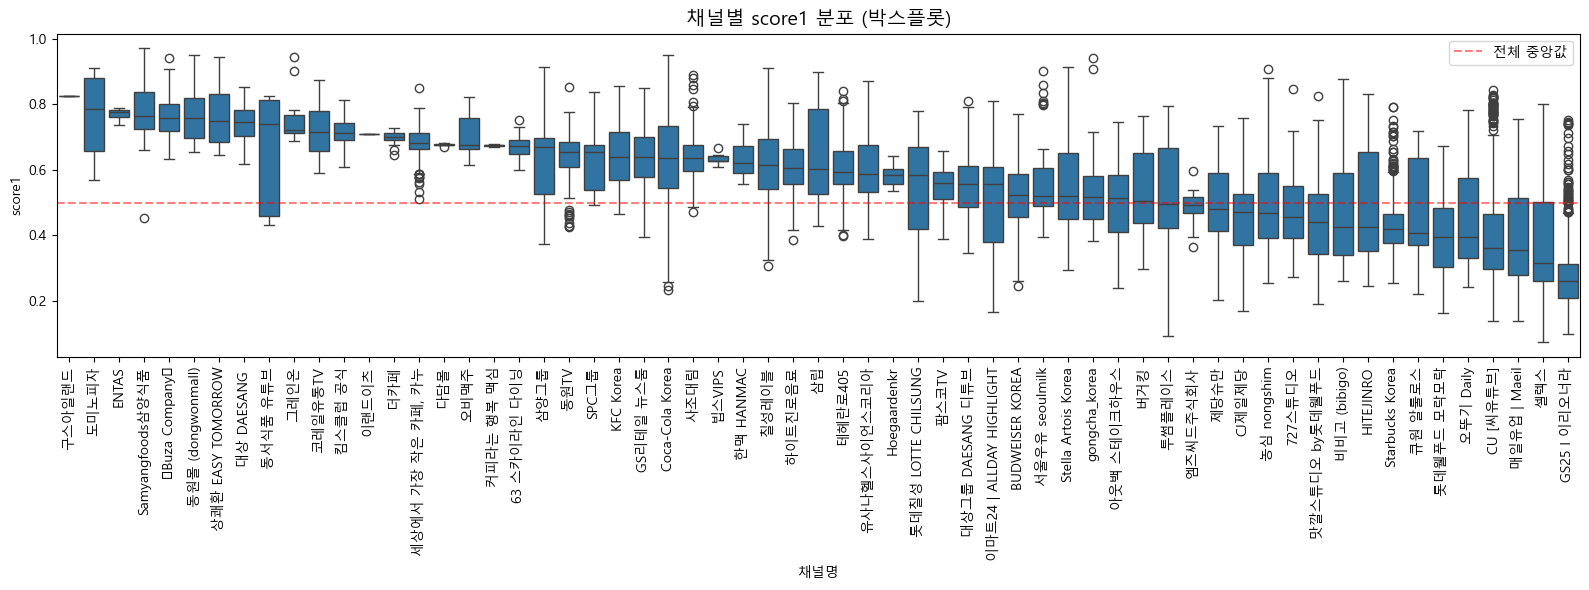

In [16]:
# 채널별 score1 분포 비교 시각화 (박스플롯)
fig, ax = plt.subplots(figsize=(16, 6))

# 채널별 score1 중앙값 기준으로 정렬
channel_order = (
    df_target_main.groupby('채널명')['score1']
    .median()
    .sort_values(ascending=False)
    .index
)

# 박스플롯 (이상치 포함 전체 분포)
sns.boxplot(
    data=df_target_main,
    x='채널명', y='score1',
    order=channel_order,
    ax=ax
)
ax.set_title('채널별 score1 분포 (박스플롯)', fontsize=14)
ax.set_xlabel('채널명')
ax.set_ylabel('score1')
ax.tick_params(axis='x', rotation=90)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='전체 중앙값')
ax.legend()

plt.tight_layout()
plt.show()

---
### **5. 지표 2**
- 일평균 조회수, 좋아요율(ler), 댓글률(cer)을 활용하는 지표
- 채널 생성 후 경과 시간에 관계없이 특정 영상이 업로드되기 직전 3개월 동안
  업로드된 영상들의 평균값을 기준으로 해당 영상의 상대적 성과를 측정
- 직전 3개월 참조 영상에서 해당 영상 자신은 제외
- 참조 영상이 0개인 경우 (채널 초기 영상) → 지표 2 계산 제외

- 3가지 성과 지표
    - 조회수 성과 = 해당 영상의 일평균 조회수 / 직전 3개월 영상들의 평균 일평균 조회수
    - 좋아요 성과 = 해당 영상의 좋아요율(ler) / 직전 3개월 영상들의 평균 좋아요율
    - 댓글 성과  = 해당 영상의 댓글률(cer) / 직전 3개월 영상들의 평균 댓글률

- 가중치를 구하는 방법 (후보)
    - CV 기반
        - 3가지 성과 지표 각각의 CV를 구해서 변별력이 높은 지표에 높은 가중치 부여
    - PCA 기반
        - 변수가 3개이므로 PC1의 loading을 가중치로 사용 가능
        - CV 기반과 비교 후 선택

In [17]:
# 같은 채널에서 같은 날 업로드된 영상 확인
# 직전 3개월 참조 그룹 계산 시 동일 날짜 처리 방침 결정을 위해
same_day = df_target_main.groupby(['channel_id', 'upload_ymd']).size()
same_day = same_day[same_day > 1]

print(f"같은 날 2개 이상 업로드된 경우: {len(same_day)}건") # 908건

같은 날 2개 이상 업로드된 경우: 908건


In [18]:
# 채널별 같은 날 2개 이상 업로드된 건수 확인
same_day_by_channel = (
    df_target_main.groupby(['channel_id', 'upload_ymd']).size()
    .reset_index(name='daily_count')
)

# 하루에 2개 이상 업로드된 날만 필터링
same_day_by_channel = same_day_by_channel[same_day_by_channel['daily_count'] > 1]

# 채널별 집계
same_day_summary = (
    same_day_by_channel.groupby('channel_id')
    .agg(
        중복업로드_날짜수=('upload_ymd', 'count'),
        중복업로드_최대=('daily_count', 'max')
    )
    .reset_index()
)

# 채널명 붙이기
same_day_summary = same_day_summary.merge(
    df_target_main[['channel_id', '채널명']].drop_duplicates(),
    on='channel_id'
)

# 결과 데이터 프레임
result = (
    same_day_summary[['채널명', '중복업로드_날짜수', '중복업로드_최대']]
    .sort_values('중복업로드_날짜수', ascending=False)
    .reset_index(drop=True)
)

print(f"같은 날 2개 이상 업로드한 채널 수: {len(same_day_summary)}개")
print(f"\n[채널별 중복 업로드 현황]")
display(result)

같은 날 2개 이상 업로드한 채널 수: 50개

[채널별 중복 업로드 현황]


,채널명,중복업로드_날짜수,중복업로드_최대
0,GS25 l 이리오너라,135,5
1,이마트24 | ALLDAY HIGHLIGHT,93,7
2,Starbucks Korea,77,8
3,CU [씨유튜브],67,5
4,CJ제일제당,40,6
5,오뚜기 Daily,39,7
6,동원TV,38,4
7,칠성레이블,38,7
8,Coca-Cola Korea,37,5
9,매일유업 | Maeil,30,5


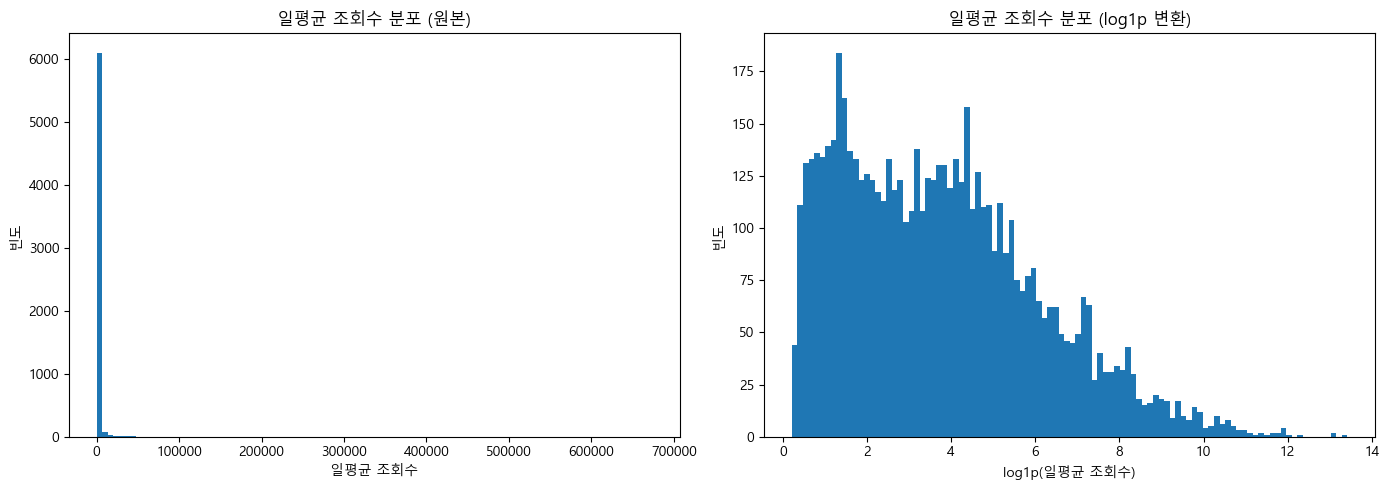

원본 왜도: 32.0081
로그변환 후 왜도: 0.6627


In [19]:
# 일평균 조회수 성과에서 로그변환이 필요한지 판단
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 원본 분포
axes[0].hist(df_target_main['일평균 조회수'], bins=100, edgecolor='none')
axes[0].set_title('일평균 조회수 분포 (원본)')
axes[0].set_xlabel('일평균 조회수')
axes[0].set_ylabel('빈도')

# 2. 로그변환 후 분포
axes[1].hist(np.log1p(df_target_main['일평균 조회수']), bins=100, edgecolor='none')
axes[1].set_title('일평균 조회수 분포 (log1p 변환)')
axes[1].set_xlabel('log1p(일평균 조회수)')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

# 왜도(skewness) 확인
from scipy.stats import skew
print(f"원본 왜도: {skew(df_target_main['일평균 조회수']):.4f}")
print(f"로그변환 후 왜도: {skew(np.log1p(df_target_main['일평균 조회수'])):.4f}")

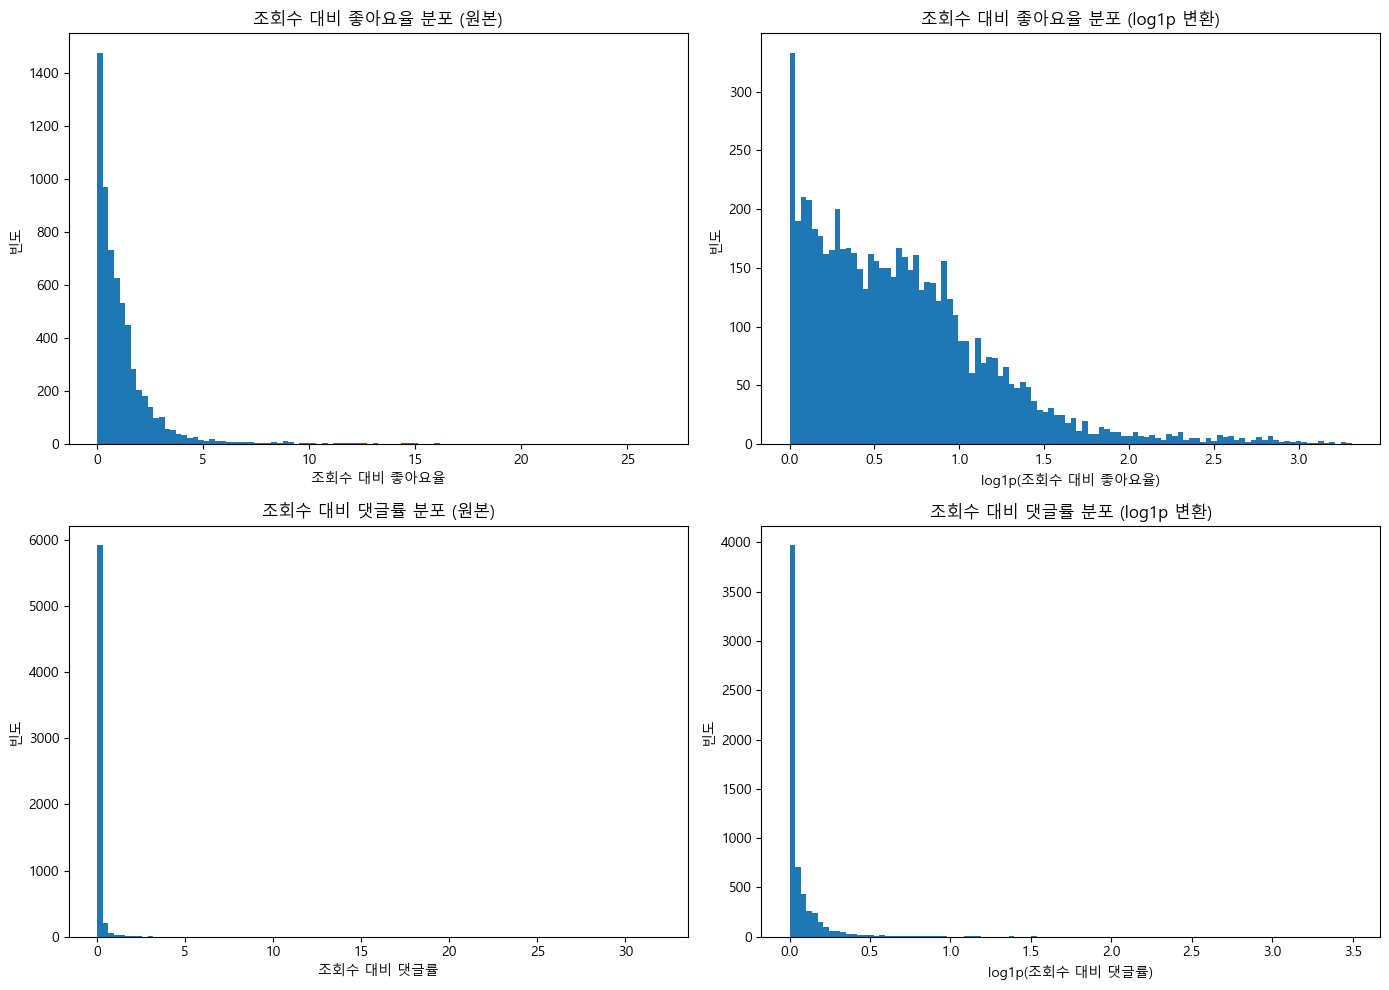

[조회수 대비 좋아요율]
  원본 왜도     : 5.0964
  로그변환 후 왜도: 1.3460
[조회수 대비 댓글률]
  원본 왜도     : 25.7539
  로그변환 후 왜도: 7.8074


In [20]:
# 좋아요율, 댓글률의 데이터 분포 확인
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['조회수 대비 좋아요율', '조회수 대비 댓글률']):
    # 원본
    axes[i][0].hist(df_target_main[col], bins=100, edgecolor='none')
    axes[i][0].set_title(f'{col} 분포 (원본)')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('빈도')

    # 로그변환
    axes[i][1].hist(np.log1p(df_target_main[col]), bins=100, edgecolor='none')
    axes[i][1].set_title(f'{col} 분포 (log1p 변환)')
    axes[i][1].set_xlabel(f'log1p({col})')
    axes[i][1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

# 왜도 확인
for col in ['조회수 대비 좋아요율', '조회수 대비 댓글률']:
    print(f"[{col}]")
    print(f"  원본 왜도     : {skew(df_target_main[col]):.4f}")
    print(f"  로그변환 후 왜도: {skew(np.log1p(df_target_main[col])):.4f}")

In [21]:
print(f"댓글률 = 0인 영상 수: {(df_target_main['조회수 대비 댓글률'] == 0).sum()}개")
print(f"전체 대비 비율: {(df_target_main['조회수 대비 댓글률'] == 0).mean()*100:.1f}%")

print(f"\n좋아요율 = 0인 영상 수: {(df_target_main['조회수 대비 좋아요율'] == 0).sum()}개")
print(f"전체 대비 비율: {(df_target_main['조회수 대비 좋아요율'] == 0).mean()*100:.1f}%")

댓글률 = 0인 영상 수: 1942개
전체 대비 비율: 30.9%

좋아요율 = 0인 영상 수: 7개
전체 대비 비율: 0.1%


---
- 기본적인 데이터 분포 확인 결과
    - 공통: 댓글성과는 왜도가 높고 0값이 30.9%로 많으므로 어떤 방법이든 상대적으로 낮은 가중치 부여하는 것이 좋을 것 같음

In [22]:
# -------------------------------------------------------
# 지표2 - 영상별 직전 3개월 업로드된 영상을 기반으로 조회수/댓글/좋아요 성과 계산
# 일평균 조회수, 좋아요율, 댓글률 모두 log1p 변환 적용 
# -> 원본 데이터로 계산 시, 왜도가 너무 높아 극단값 영향을 제거하기 위해
# -------------------------------------------------------

# 참조용 데이터프레임 생성
# 분석 대상 마지막 날짜(2026-03-27) 이후 영상은 참조 그룹에서 제외
ANALYSIS_END = pd.Timestamp("2026-03-27")
df_ref = df_shorts[df_shorts['upload_date'] <= ANALYSIS_END].copy()

results = []  # 영상별 지표 2 결과 저장

for idx, row in df_target_main.iterrows():

    channel_id   = row['channel_id']
    upload_date  = row['업로드일시']
    window_start = upload_date - pd.DateOffset(months=3)

    # 직전 3개월 참조 그룹 추출
    # 원본 데이터(df_ref)에서 탐색 → 버퍼 기간(2021-07-13~2021-10-12) 영상 포함
    # 같은 채널, 업로드 시각 기준 이전 영상만 포함 (해당 영상 자신 제외)
    ref = df_ref[
        (df_ref['channel_id'] == channel_id) &
        (df_ref['upload_date'] >= window_start) &
        (df_ref['upload_date'] < upload_date)
    ]

    # 참조 영상이 없으면 지표 2 계산 불가 → NaN 처리
    if len(ref) == 0:
        results.append({'video_id'  : row['video_id'],
                        '조회수성과': None,
                        '좋아요성과': None,
                        '댓글성과'  : None})
        continue

    # 참조 그룹 평균값 계산 (log1p 변환 후 평균)
    # 분모: 직전 3개월 영상들의 log1p 변환 후 평균값
    ref_avg_daily_view = np.log1p(ref['view_count'] / ref['elapsed_days']).mean()  # 일평균 조회수 직접 계산
    ref_avg_ler = np.log1p(ref['ler']).mean()
    ref_avg_cer = np.log1p(ref['cer']).mean()

    # 3가지 성과 지표 계산 (분모가 0이면 NaN 처리)
    # 조회수 성과 = log1p(해당 영상 일평균 조회수)(분자) / log1p(참조 그룹 평균 일평균 조회수)(분모)
    view_score = (np.log1p(row['일평균 조회수']) / ref_avg_daily_view
                  if ref_avg_daily_view != 0 else None)

    # 좋아요 성과 = log1p(해당 영상 좋아요율)(분자) / log1p(참조 그룹 평균 좋아요율)(분모)
    like_score = (np.log1p(row['조회수 대비 좋아요율']) / ref_avg_ler
                  if ref_avg_ler != 0 else None)

    # 댓글 성과 = log1p(해당 영상 댓글률)(분자) / log1p(참조 그룹 평균 댓글률)(분모)
    comm_score = (np.log1p(row['조회수 대비 댓글률']) / ref_avg_cer
                  if ref_avg_cer != 0 else None)

    results.append({
        'video_id'  : row['video_id'],
        '조회수성과': view_score,
        '좋아요성과': like_score,
        '댓글성과'  : comm_score
    })

# 결과 DataFrame으로 변환 후 병합
result_df = pd.DataFrame(results)
df_target_main = df_target_main.merge(result_df, on='video_id', how='left')

# 확인
print(f"[지표 2 성과 통계]")
display(df_target_main[['조회수성과', '좋아요성과', '댓글성과']].describe())

[지표 2 성과 통계]


,조회수성과,좋아요성과,댓글성과
count,6134.000000,6133.000000,5964.000000
mean,1.139116,1.156399,2.547854
std,0.967464,6.030983,26.415032
min,0.048625,0.000000,0.000000
25%,0.770858,0.528920,0.000000
50%,1.027933,0.899285,0.364081
75%,1.272305,1.284016,1.305497
max,34.329399,448.996754,1239.050643


In [23]:
# 성과지표별 상위 1%, 5% 기준값 확인
# 가중치 계산 시 이상치 제외 기준 결정을 위해
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    pct99 = df_target_main[col].quantile(0.99)
    pct95 = df_target_main[col].quantile(0.95)
    print(f"{col} - 상위 1%: {pct99:.4f} / 상위 5%: {pct95:.4f}")

조회수성과 - 상위 1%: 3.9262 / 상위 5%: 2.1272
좋아요성과 - 상위 1%: 4.4821 / 상위 5%: 2.3061
댓글성과 - 상위 1%: 25.3525 / 상위 5%: 5.1573


In [24]:
# -------------------------------------------------------
# 성과지표 이상치 flag 생성 (상위 1%, 5% 기준)
# 클리핑 없이 flag만 남기고
# 가중치 계산은 이상치 제외, score2 계산은 전체 영상에 적용
# -------------------------------------------------------
for col, flag_col_1, flag_col_5 in [
    ('조회수성과', '조회수성과_상위1%', '조회수성과_상위5%'),
    ('좋아요성과', '좋아요성과_상위1%', '좋아요성과_상위5%'),
    ('댓글성과',   '댓글성과_상위1%',   '댓글성과_상위5%')
]:
    pct99 = df_target_main[col].quantile(0.99)
    pct95 = df_target_main[col].quantile(0.95)

    # 상위 1% 초과 flag (1: 이상치, 0: 정상)
    df_target_main[flag_col_1] = (df_target_main[col] > pct99).astype(int)
    # 상위 5% 초과 flag (1: 이상치, 0: 정상)
    df_target_main[flag_col_5] = (df_target_main[col] > pct95).astype(int)

# 결과 확인
print(f"[이상치 flag 현황]")
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    cnt_1 = df_target_main[f'{col}_상위1%'].sum()
    cnt_5 = df_target_main[f'{col}_상위5%'].sum()
    print(f"{col} - 상위 1%: {cnt_1}개 / 상위 5%: {cnt_5}개")

[이상치 flag 현황]
조회수성과 - 상위 1%: 62개 / 상위 5%: 307개
좋아요성과 - 상위 1%: 62개 / 상위 5%: 307개
댓글성과 - 상위 1%: 60개 / 상위 5%: 299개


In [25]:
# -------------------------------------------------------
# 가중치 계산용 데이터프레임 생성
# 세 가지 성과지표 중 하나라도 상위 5% 이상치이거나 NaN인 영상 제외
# score2 계산은 이상치 포함 전체 영상(df_target_main)에 적용
# -------------------------------------------------------
df_weight_calc = df_target_main[
    (df_target_main['조회수성과_상위5%'] == 0) &
    (df_target_main['좋아요성과_상위5%'] == 0) &
    (df_target_main['댓글성과_상위5%'] == 0) &
    (df_target_main['조회수성과'].notna()) &
    (df_target_main['좋아요성과'].notna()) &
    (df_target_main['댓글성과'].notna())
].copy()

print(f"전체 영상 수: {len(df_target_main)}")
print(f"가중치 계산용 영상 수: {len(df_weight_calc)}")
print(f"제외된 영상 수: {len(df_target_main) - len(df_weight_calc)}")
print(f"\n[가중치 계산용 데이터 왜도]")
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    print(f"  {col}: {skew(df_weight_calc[col]):.4f}")

전체 영상 수: 6281
가중치 계산용 영상 수: 5177
제외된 영상 수: 1104

[가중치 계산용 데이터 왜도]
  조회수성과: 0.2536
  좋아요성과: 0.3823
  댓글성과: 1.7364


In [26]:
# -------------------------------------------------------
# 지표 2 - CV 기반 가중치(a, b, c) 산출
# 변별력이 높은 성과지표에 높은 가중치 부여
# -------------------------------------------------------

# CV = 표준편차 / 평균
cv_view = df_weight_calc['조회수성과'].std() / df_weight_calc['조회수성과'].mean()
cv_like = df_weight_calc['좋아요성과'].std() / df_weight_calc['좋아요성과'].mean()
cv_comm = df_weight_calc['댓글성과'].std()   / df_weight_calc['댓글성과'].mean()
cv_sum  = cv_view + cv_like + cv_comm

a_cv = cv_view / cv_sum  # 조회수성과 가중치
b_cv = cv_like / cv_sum  # 좋아요성과 가중치
c_cv = cv_comm / cv_sum  # 댓글성과 가중치

print(f"[CV 기반 가중치]")
print(f"a (조회수성과): {a_cv:.4f}")
print(f"b (좋아요성과): {b_cv:.4f}")
print(f"c (댓글성과)  : {c_cv:.4f}")
print(f"합계: {a_cv + b_cv + c_cv:.4f}")

# 댓글의 왜도가 가장 컸는데,
# 댓글성과의 분포를 보면 25%의 임계값도 0으로 댓글이 없는 경우가 많아서 변동성이 커진 것으로 보는 것이
# 더 합리적인 것으로 보이기 때문에 PCA 방식으로도 계산해보려고 함

[CV 기반 가중치]
a (조회수성과): 0.1606
b (좋아요성과): 0.2455
c (댓글성과)  : 0.5938
합계: 1.0000


In [27]:
# -------------------------------------------------------
# 지표 2 - PCA 기반 가중치(a, b, c) 산출
# 변수가 3개이므로 PC1의 loading(기여도)을 가중치로 사용 가능
# -------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA 입력 데이터 준비 (조회수성과, 좋아요성과, 댓글성과)
X = df_weight_calc[['조회수성과', '좋아요성과', '댓글성과']].values

# 표준화 (단위가 다른 세 지표를 같은 스케일로 맞춤)
# 댓글 성과의 표준편차가 다른 지표에 비해 유독 커서 모든 지표를 0~1 사이의 값으로 정규화함
X_scaled = StandardScaler().fit_transform(X)

# PCA 수행
pca = PCA(n_components=3)
pca.fit(X_scaled)
# pca.fit() 안에서:
# (1) X_scaled의 공분산 행렬 계산
# (2) 고유값 분해로 PC1, PC2, PC3 방향 탐색
# (3) 고유값 크기 순으로 주성분 정렬

# 공분산 행렬 출력
cov_matrix = pd.DataFrame(
    np.cov(X_scaled.T),
    index=['조회수성과', '좋아요성과', '댓글성과'],
    columns=['조회수성과', '좋아요성과', '댓글성과']
)
print(f"[공분산 행렬]")
display(cov_matrix.round(2))

# PC1의 각 변수 기여도(loading) 절댓값을 가중치로 사용
loadings = np.abs(pca.components_[0])  # PC1의 loading
a_pca, b_pca, c_pca = loadings / loadings.sum()  # 합이 1이 되도록 정규화

print(f"[PCA 기반 가중치]")
print(f"a (조회수성과): {a_pca:.4f}")
print(f"b (좋아요성과): {b_pca:.4f}")
print(f"c (댓글성과)  : {c_pca:.4f}")
print(f"합계: {a_pca + b_pca + c_pca:.4f}")
print(f"\nPC1 설명력: {pca.explained_variance_ratio_[0]*100:.1f}%")

print(f"\n[CV vs PCA 가중치 비교]")
print(f"a (조회수성과) → CV: {a_cv:.4f} / PCA: {a_pca:.4f}")
print(f"b (좋아요성과) → CV: {b_cv:.4f} / PCA: {b_pca:.4f}")
print(f"c (댓글성과)   → CV: {c_cv:.4f} / PCA: {c_pca:.4f}")

[공분산 행렬]


,조회수성과,좋아요성과,댓글성과
조회수성과,1.00,-0.39,-0.20
좋아요성과,-0.39,1.00,0.32
댓글성과,-0.20,0.32,1.00


[PCA 기반 가중치]
a (조회수성과): 0.3313
b (좋아요성과): 0.3688
c (댓글성과)  : 0.2999
합계: 1.0000

PC1 설명력: 53.8%

[CV vs PCA 가중치 비교]
a (조회수성과) → CV: 0.1606 / PCA: 0.3313
b (좋아요성과) → CV: 0.2455 / PCA: 0.3688
c (댓글성과)   → CV: 0.5938 / PCA: 0.2999


In [28]:
# -------------------------------------------------------
# score2 계산 함수 정의
# 성과지표 결측 상황에 따라 가중치 재조정
# 단, 조회수성과가 없거나 2개 이상 지표가 없으면 제외
# -------------------------------------------------------
def calc_score2(row, a, b, c):

    view = row['조회수성과']
    like = row['좋아요성과']
    comm = row['댓글성과']

    # 조회수성과가 없는 경우
    # → 참조 그룹의 평균 일평균 조회수가 0인 경우로 데이터 오류 가능성이 높아 제외
    if pd.isna(view):
        return None

    # 세 지표 모두 있는 경우
    if pd.notna(like) and pd.notna(comm):
        return a*view + b*like + c*comm

    # 좋아요성과만 없는 경우 → a, c 재조정
    elif pd.isna(like) and pd.notna(comm):
        a_new = a / (a + c)
        c_new = c / (a + c)
        return a_new*view + c_new*comm

    # 댓글성과만 없는 경우 → a, b 재조정
    elif pd.notna(like) and pd.isna(comm):
        a_new = a / (a + b)
        b_new = b / (a + b)
        return a_new*view + b_new*like

    # 좋아요성과, 댓글성과 모두 없는 경우
    # → 조회수성과만으로는 신뢰도가 낮으므로 제외
    else:
        return None

# PCA 기반 가중치로 score2 계산
df_target_main['score2'] = df_target_main.apply(
    lambda row: calc_score2(row, a_pca, b_pca, c_pca), axis=1
)

# 확인
print(f"[score2 결측값 현황]")
print(f"전체 영상 수: {len(df_target_main)}")
print(f"score2 계산 가능: {df_target_main['score2'].notna().sum()}개")
print(f"score2 결측값: {df_target_main['score2'].isna().sum()}개")
print(f"\n[score2 통계]")
print(df_target_main['score2'].describe())

[score2 결측값 현황]
전체 영상 수: 6281
score2 계산 가능: 6133개
score2 결측값: 148개

[score2 통계]
count    6133.000000
mean        1.560780
std         8.276035
min         0.100835
25%         0.646578
50%         0.873228
75%         1.250429
max       372.446588
Name: score2, dtype: float64


In [29]:
# score2 결측값 제거 후 분석용 데이터프레임 생성
df_target_main2 = df_target_main.dropna(subset=['score2']).copy()

print(f"\n분석 대상 영상 수: {len(df_target_main2)}")


분석 대상 영상 수: 6133


In [30]:
# df_target_main2 기준 성과지표 통계 확인
print(f"[성과지표 통계]")
display(df_target_main2[['조회수성과', '좋아요성과', '댓글성과']].describe())

# 왜도 확인 (NaN 제외 후 계산)
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    print(f"{col} 왜도: {skew(df_target_main2[col].dropna()):.4f}")

[성과지표 통계]


,조회수성과,좋아요성과,댓글성과
count,6133.000000,6133.000000,5964.000000
mean,1.138241,1.156399,2.547854
std,0.965112,6.030983,26.415032
min,0.048625,0.000000,0.000000
25%,0.770786,0.528920,0.000000
50%,1.027922,0.899285,0.364081
75%,1.272198,1.284016,1.305497
max,34.329399,448.996754,1239.050643


조회수성과 왜도: 14.2999
좋아요성과 왜도: 67.6321
댓글성과 왜도: 31.0626


In [31]:
# score1, score2 둘 다 있는지 확인
print(f"score1 결측값: {df_target_main2['score1'].isna().sum()}개")
print(f"score2 결측값: {df_target_main2['score2'].isna().sum()}개")
print(f"\n[score1 통계]")
print(df_target_main2['score1'].describe())
print(f"\n[score2 통계]")
print(df_target_main2['score2'].describe())

score1 결측값: 0개
score2 결측값: 0개

[score1 통계]
count    6133.000000
mean        0.497787
std         0.171308
min         0.073335
25%         0.356951
50%         0.504852
75%         0.632492
max         0.970780
Name: score1, dtype: float64

[score2 통계]
count    6133.000000
mean        1.560780
std         8.276035
min         0.100835
25%         0.646578
50%         0.873228
75%         1.250429
max       372.446588
Name: score2, dtype: float64


---
### 두 지표 비교

In [32]:
# -------------------------------------------------------
# core1 vs score2 상관관계 분석
# -------------------------------------------------------
df_both = df_target_main2[['score1', 'score2']].dropna()

corr, p_value = stats.spearmanr(df_both['score1'], df_both['score2'])

print(f"[score1 vs score2 Spearman 상관계수]")
print(f"상관계수: {corr:.4f}")
print(f"p-value : {p_value:.4e}")
print(f"샘플 수 : {len(df_both)}")

[score1 vs score2 Spearman 상관계수]
상관계수: 0.2046
p-value : 5.9818e-59
샘플 수 : 6133


In [33]:
# -------------------------------------------------------
# Step 2. 채널별 변별력 비교
# -------------------------------------------------------
score1_var = df_target_main2.groupby('채널명')['score1'].median().var()
score2_var = df_target_main2.groupby('채널명')['score2'].median().var()

print(f"score1 채널별 중앙값 분산: {score1_var:.4f}")
print(f"score2 채널별 중앙값 분산: {score2_var:.4f}")

score1 채널별 중앙값 분산: 0.0168
score2 채널별 중앙값 분산: 0.0258


In [34]:
# -------------------------------------------------------
# 두 지표 모두 상위/하위 25% 영상 수 확인
# -------------------------------------------------------
q75_s1 = df_target_main2['score1'].quantile(0.75)
q25_s1 = df_target_main2['score1'].quantile(0.25)
q75_s2 = df_target_main2['score2'].quantile(0.75)
q25_s2 = df_target_main2['score2'].quantile(0.25)

both_top = df_target_main2[
    (df_target_main2['score1'] >= q75_s1) &
    (df_target_main2['score2'] >= q75_s2)
]
both_bottom = df_target_main2[
    (df_target_main2['score1'] <= q25_s1) &
    (df_target_main2['score2'] <= q25_s2)
]

print(f"[두 지표 모두 상위 25%]")
print(f"영상 수: {len(both_top)}개 ({len(both_top)/len(df_target_main2)*100:.1f}%)")
print(f"\n[두 지표 모두 하위 25%]")
print(f"영상 수: {len(both_bottom)}개 ({len(both_bottom)/len(df_target_main2)*100:.1f}%)")

[두 지표 모두 상위 25%]
영상 수: 530개 (8.6%)

[두 지표 모두 하위 25%]
영상 수: 526개 (8.6%)


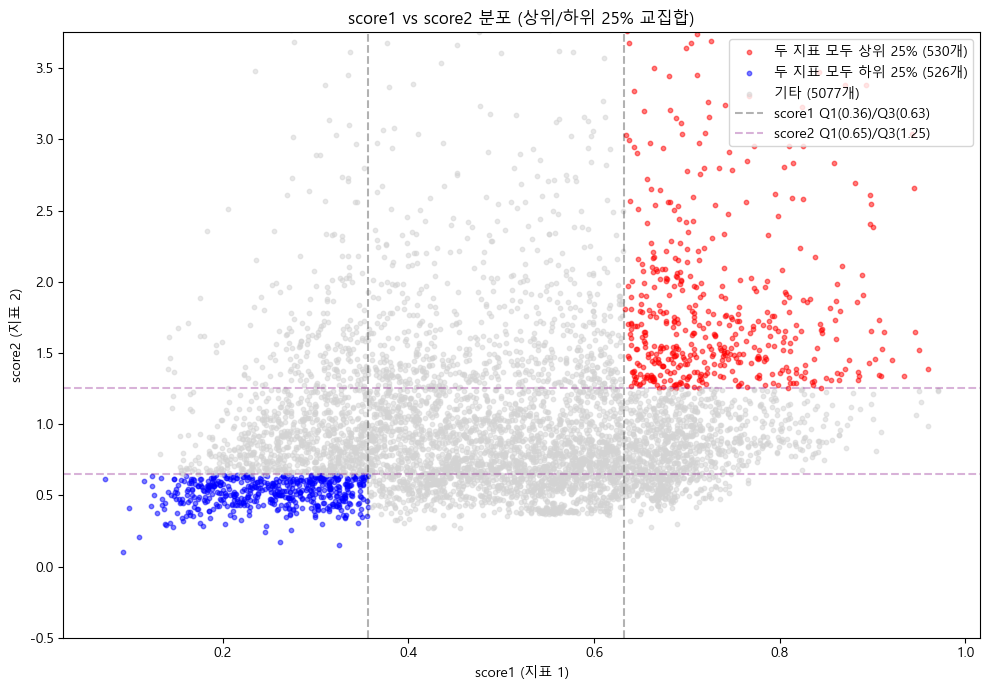

In [35]:
# -------------------------------------------------------
# 두 지표 상위/하위 25% 교집합 시각화
# -------------------------------------------------------

# 그룹 분류
conditions = [
    (df_target_main2['score1'] >= q75_s1) & (df_target_main2['score2'] >= q75_s2),
    (df_target_main2['score1'] <= q25_s1) & (df_target_main2['score2'] <= q25_s2),
]
choices = ['두 지표 모두 상위 25%', '두 지표 모두 하위 25%']
df_target_main2['group'] = np.select(conditions, choices, default='기타')

color_map = {
    '두 지표 모두 상위 25%': 'red',
    '두 지표 모두 하위 25%': 'blue',
    '기타': 'lightgray'
}

fig, ax = plt.subplots(figsize=(10, 7))

for group, color in color_map.items():
    subset = df_target_main2[df_target_main2['group'] == group]
    ax.scatter(
        subset['score1'], subset['score2'],
        c=color, label=f"{group} ({len(subset)}개)",
        alpha=0.5, s=10
    )

ax.axvline(x=q25_s1, color='black', linestyle='--', alpha=0.3, label=f'score1 Q1({q25_s1:.2f})/Q3({q75_s1:.2f})')
ax.axvline(x=q75_s1, color='black', linestyle='--', alpha=0.3)
ax.axhline(y=q25_s2, color='purple', linestyle='--', alpha=0.3, label=f'score2 Q1({q25_s2:.2f})/Q3({q75_s2:.2f})')
ax.axhline(y=q75_s2, color='purple', linestyle='--', alpha=0.3)

ax.set_xlabel('score1 (지표 1)')
ax.set_ylabel('score2 (지표 2)')
ax.set_ylim(-0.5, q75_s2 * 3)
ax.set_title('score1 vs score2 분포 (상위/하위 25% 교집합)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()